In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from sklearn.model_selection import train_test_split

    Train  Validate
g1     44        12
g2     41        11
g3     40        11
g4     33         9
g5     22         6
g6     16         5
Total Training: 196
Total Testing: 54


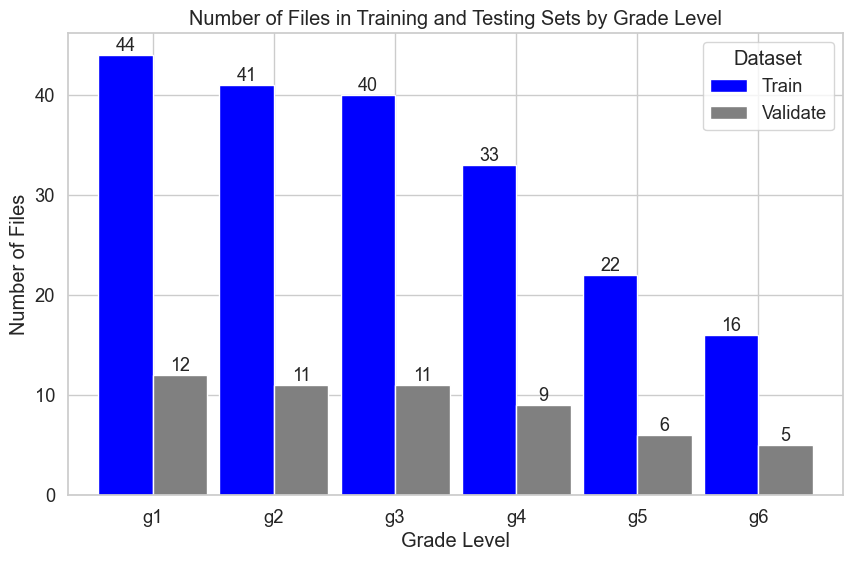

In [19]:
base_dir = "../txt/utf"
test_size=0.2
random_seed=42

train_files = []
test_files = []

# Iterate over each immediate subdirectory (grade-level folder)
for grade_dir in os.listdir(base_dir):
    grade_path = os.path.join(base_dir, grade_dir)

    if not os.path.isdir(grade_path):
        continue  # Skip files in base_dir

    all_files = []
    for root, _, files in os.walk(grade_path):
        for file in files:
            full_path = os.path.join(root, file)
            if file.endswith(".txt"):
                all_files.append(full_path)
            elif file.endswith(".pdf"):
                print(f"{file} in {grade_path} is a PDF. Please convert to TXT.")
            elif file.endswith(".docx"):
                print(f"{file} in {grade_path} is a DOCX. Please convert to TXT.")
            else:
                print(f"Unsupported file type: {file}. Skipping.")

    if all_files:
        random.seed(random_seed)
        random.shuffle(all_files)
        train_split, test_split = train_test_split(
            all_files, test_size=test_size, random_state=random_seed
        )
        train_files.extend(train_split)
        test_files.extend(test_split)

# Count the number of files for each grade level in training and testing sets
train_grades = [os.path.basename(os.path.dirname(file)) for file in train_files]
test_grades = [os.path.basename(os.path.dirname(file)) for file in test_files]

train_grade_counts = pd.Series(train_grades).value_counts().sort_index()
test_grade_counts = pd.Series(test_grades).value_counts().sort_index()

# Create a DataFrame to display the counts
grade_data = pd.DataFrame({
    'Train': train_grade_counts,
    'Validate': test_grade_counts
}).fillna(0)  # Fill NaN with 0 for missing grade levels

# Print the counts
print(grade_data)
print(f"Total Training: {len(train_files)}")
print(f"Total Testing: {len(test_files)}")

# Plot the counts
# grade_data.plot(kind='bar', figsize=(10, 6), color=['blue', 'orange'])
# plt.title('Number of Files in Training and Testing Sets by Grade Level')
# plt.xlabel('Grade Level')
# plt.ylabel('Number of Files')
# plt.xticks(rotation=0)
# plt.legend(title='Dataset')
# plt.show()

ax = grade_data.plot(kind='bar', figsize=(10, 6), color=['blue', 'gray'], width = 0.9)
plt.title('Number of Files in Training and Testing Sets by Grade Level')
plt.xlabel('Grade Level')
plt.ylabel('Number of Files')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=13)

plt.show()

In [ ]:
df = pd.read_csv('../tables/dataset.csv')
df = df[df['text_num'] != 18]
# df = df[df['stride_len'] != 100]
# df = df[df['grade_level'] != 1]
# df = df[df['grade_level'] != 2]
# df = df[df['grade_level'] != 4]
df = df.drop(columns=['stride_index', 'n_gram', 'word_num'], axis=1)
df["grade_level"] = df["grade_level"].astype("category")

print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   text_num grade_level  stride_len  noun_tr  verb_tr  type_tr  lex_density  \
0        79           6           1      0.0      0.0      1.0          0.0   
1        79           6           1      1.0      0.0      1.0          1.0   
2        79           6           1      1.0      0.0      1.0          1.0   
3        79           6           1      0.0      0.0      1.0          0.0   
4        79           6           1      0.0      1.0      1.0          1.0   

   lex_foreign  sent_len  word_len  syll_num  poly_num  
0          0.0    12.375       2.0       0.0         0  
1          0.0    12.375       4.0       1.0         0  
2          0.0    12.375       5.0       2.0         1  
3          0.0    12.375       2.0       0.0         0  
4          0.0    12.375       9.0       3.0         1  


In [34]:
df_show = pd.read_csv('../tables/dataset.csv')
df_show = df_show.drop(columns=['stride_index', 'word_num'], axis=1)
df_show = df_show[df_show['stride_len'] == 3]
print("Sample dataset content:")
print(df_show.head())

Sample dataset content:
     text_num  grade_level  stride_len              n_gram  noun_tr  verb_tr  \
197        79            6           3       si Shah Jahan   0.6667   0.0000   
198        79            6           3       Shah Jahan ay   0.6667   0.0000   
199        79            6           3  Jahan ay nagpatayo   0.3333   0.3333   
200        79            6           3     ay nagpatayo sa   0.0000   0.3333   
201        79            6           3  nagpatayo sa isang   0.0000   0.3333   

     type_tr  lex_density  lex_foreign  sent_len  word_len  syll_num  poly_num  
197      1.0       0.6667          0.0    12.375     3.667     1.000         1  
198      1.0       0.6667          0.0    12.375     3.667     1.000         1  
199      1.0       0.6667          0.0    12.375     5.333     1.667         2  
200      1.0       0.3333          0.0    12.375     4.333     1.000         1  
201      1.0       0.3333          0.0    12.375     5.333     1.333         1  


In [22]:
# Feature data type
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371817 entries, 0 to 371816
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   text_num     371817 non-null  int64   
 1   grade_level  371817 non-null  category
 2   stride_len   371817 non-null  int64   
 3   noun_tr      371817 non-null  float64 
 4   verb_tr      371817 non-null  float64 
 5   type_tr      371817 non-null  float64 
 6   lex_density  371817 non-null  float64 
 7   lex_foreign  371817 non-null  float64 
 8   sent_len     371817 non-null  float64 
 9   word_len     371817 non-null  float64 
 10  syll_num     371817 non-null  float64 
 11  poly_num     371817 non-null  int64   
dtypes: category(1), float64(8), int64(3)
memory usage: 31.6 MB
None


In [23]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
text_num       0
grade_level    0
stride_len     0
noun_tr        0
verb_tr        0
type_tr        0
lex_density    0
lex_foreign    0
sent_len       0
word_len       0
syll_num       0
poly_num       0
dtype: int64


In [24]:
# Summary statistics of numerical columns
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
            text_num     stride_len        noun_tr        verb_tr  \
count  371817.000000  371817.000000  371817.000000  371817.000000   
mean      147.666841      22.289228       0.250359       0.134628   
std       129.611411      39.424199       0.291439       0.228069   
min         1.000000       1.000000       0.000000       0.000000   
25%        34.000000       1.000000       0.000000       0.000000   
50%        62.000000       2.000000       0.214300       0.000000   
75%       295.000000       3.000000       0.333300       0.166700   
max       352.000000     113.000000       1.000000       1.000000   

             type_tr    lex_density    lex_foreign       sent_len  \
count  371817.000000  371817.000000  371817.000000  371817.000000   
mean        0.924407       0.526045       0.007752      10.902811   
std         0.148208       0.317568       0.062596       3.179335   
min         0.220000       0.000000       0.000000       3.500000   
25%         

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/1845607657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='grade_level', data=df, palette='Blues')


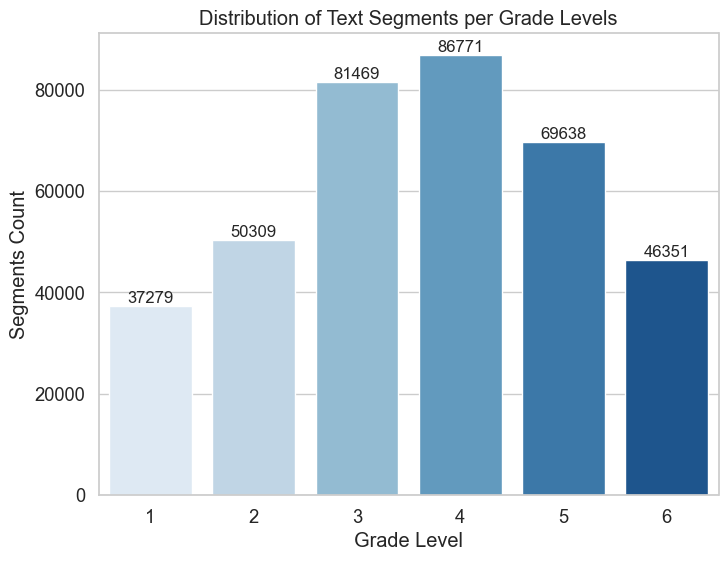

In [25]:
# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='grade_level', data=df, palette='Blues')
plt.title('Distribution of Text Segments per Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Segments Count')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=12)

plt.show()

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/343296769.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['1_gram', '2_gram', '3_gram', 'sent_frag'])


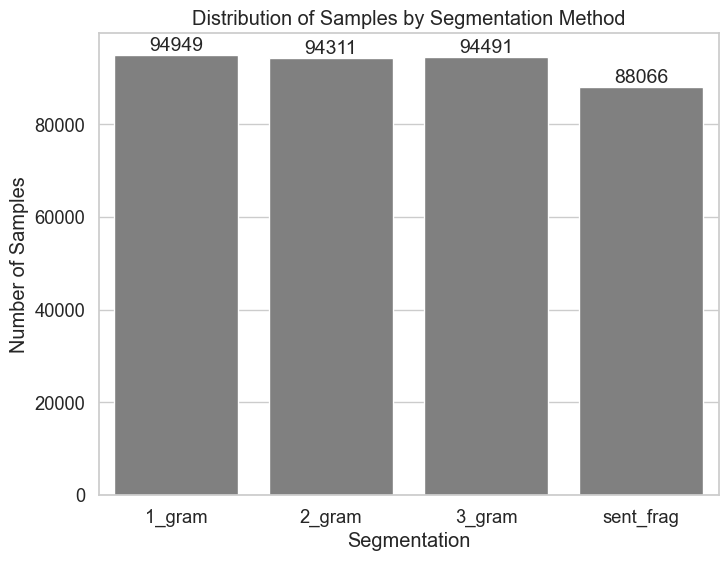

In [26]:
# Group stride_len into 4 categories: 1, 2, 3, and Other (excluding 100)
df_grouped = df[df['stride_len'] != 0].copy()
df_grouped['stride_group'] = df_grouped['stride_len'].apply(
    # lambda x: str(x) if x in [1, 2, 3] else 'Other'
    lambda x: str(x) if x in [1, 2, 3] else 'sent_frag'
)

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='stride_group', data=df_grouped, color='Gray')
plt.title('Distribution of Samples by Segmentation Method')
plt.xlabel('Segmentation')
plt.ylabel('Number of Samples')

ax.set_xticklabels(['1_gram', '2_gram', '3_gram', 'sent_frag'])
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=14)

plt.show()

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/1221239987.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/1221239987.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)



Grade level counts after undersampling:


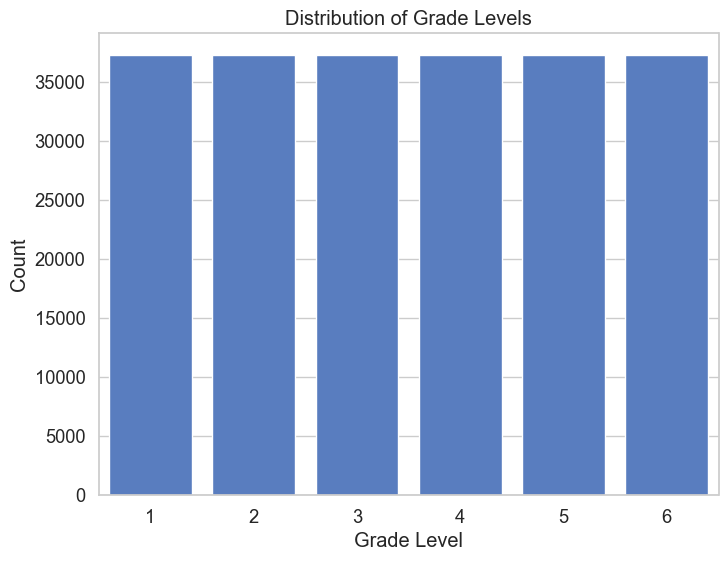

In [27]:
# Undersample the dataset to have an equal number of entries for each grade level
def undersample_dataset(df, grade_column):
    # Find the minimum count of entries across all grade levels
    min_count = df[grade_column].value_counts().min()
    # Group by grade level and sample min_count entries from each group
    undersampled_df = df.groupby(grade_column).apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
    return undersampled_df

# Apply undersampling to the dataset
df_undersampled = undersample_dataset(df, 'grade_level')

# Display the count of entries per grade level after undersampling
print("\nGrade level counts after undersampling:")

# Visualize the distribution of the dependent variable (grade_level)
plt.figure(figsize=(8, 6))
sns.countplot(x='grade_level', data=df_undersampled)
plt.title('Distribution of Grade Levels')
plt.xlabel('Grade Level')
plt.ylabel('Count')
plt.show()

/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/3399497747.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


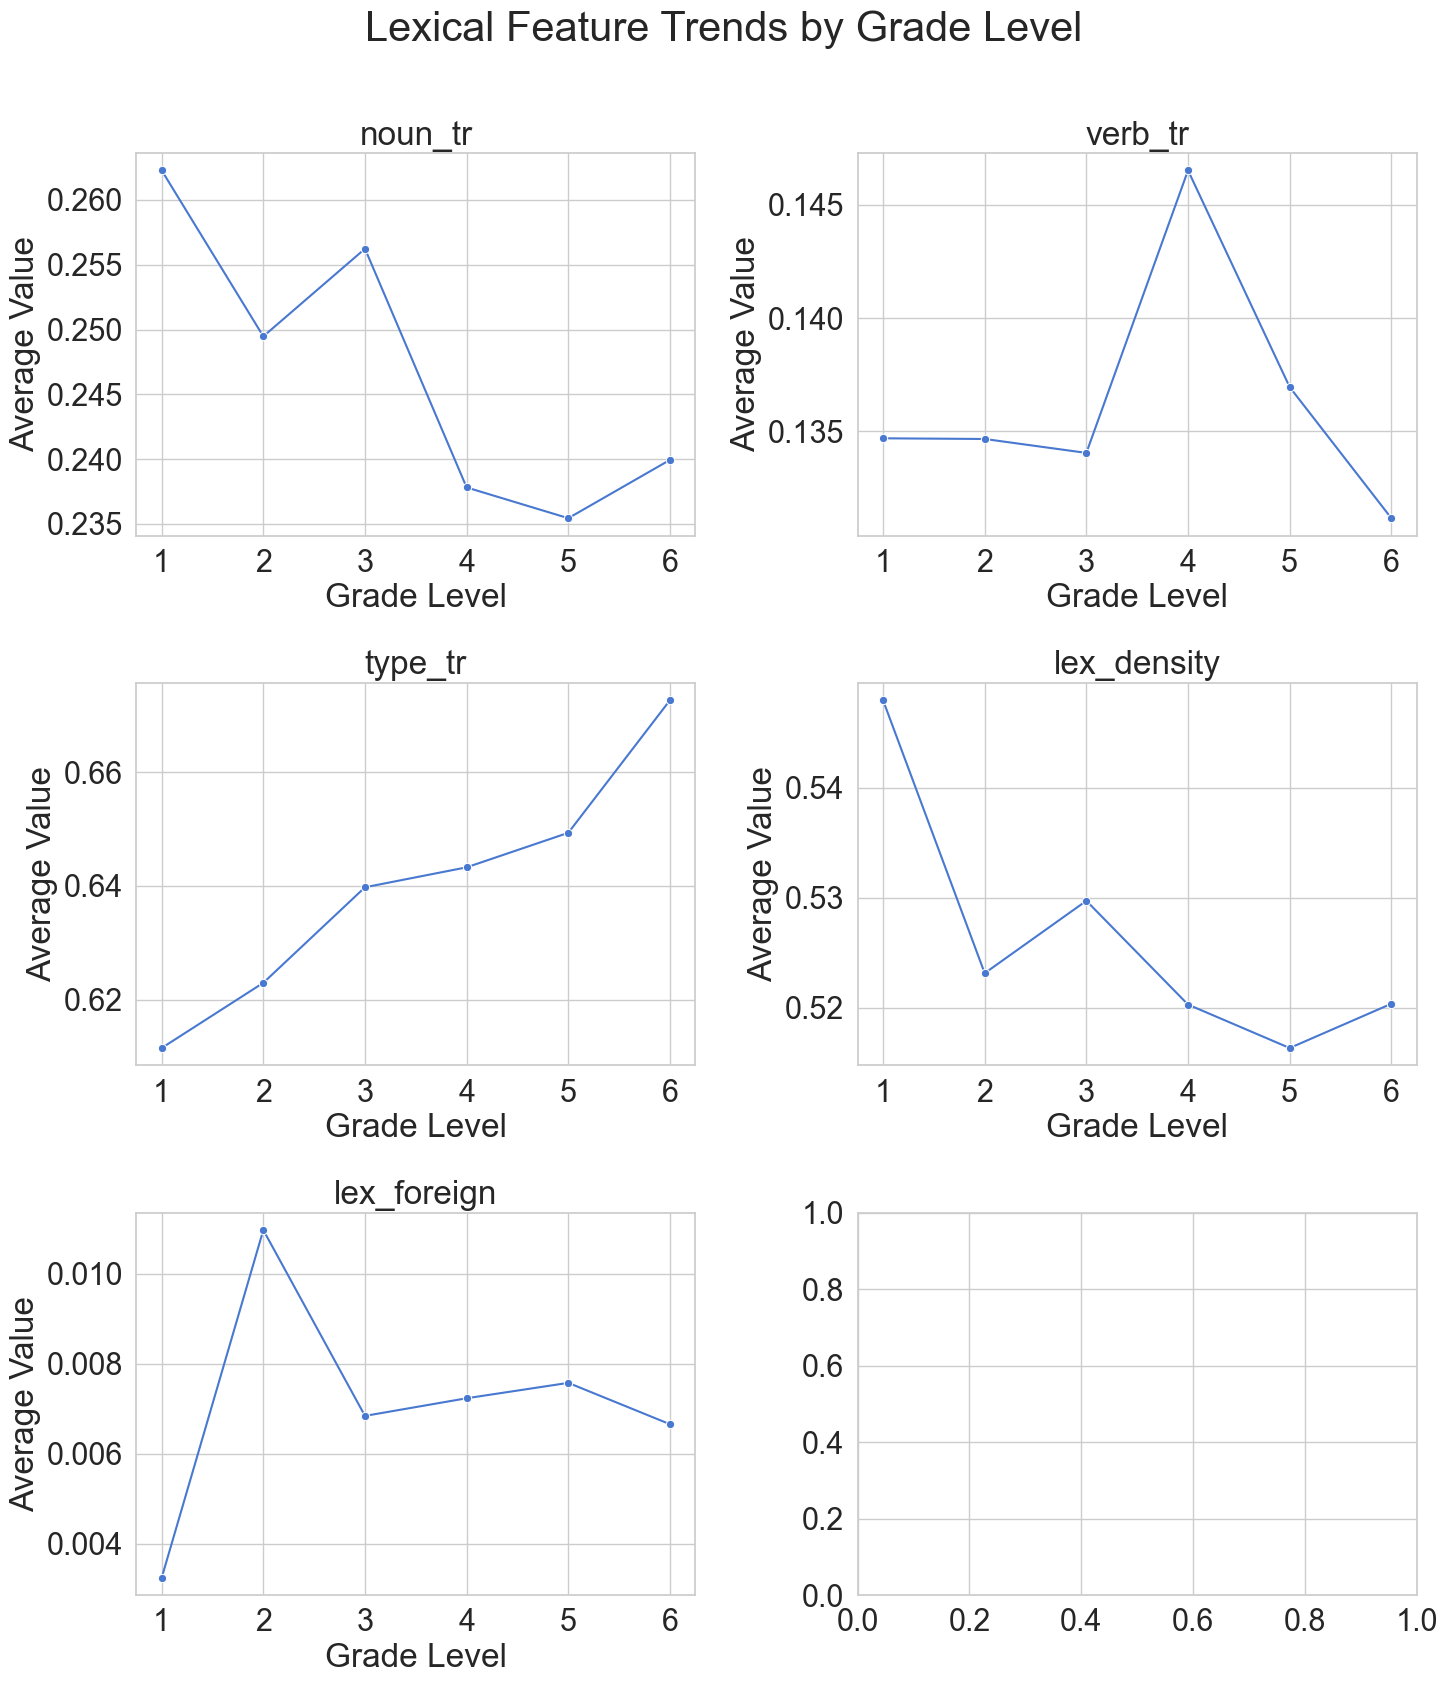

In [28]:

stride = [100]
for s in stride:
    df_filtered = df_undersampled[df_undersampled['stride_len'] == s]
    database_name = f"Stride len: {s}"

    feature_cols = [
        "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign"
    ]

    # Group by grade_level and compute average feature values
    grouped = df_filtered.groupby("grade_level")[feature_cols].mean()

    # Plot setup
    sns.set(style="whitegrid", palette="muted", font_scale=2)
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 17))
    axes = axes.flatten()

    # Plot each feature
    for i, feature in enumerate(grouped.columns):
        sns.lineplot(
            x=grouped.index.astype(str),
            y=grouped[feature],
            marker='o',
            ax=axes[i]
        )
        axes[i].set_title(f"{feature}")
        axes[i].set_xlabel("Grade Level")
        axes[i].set_ylabel("Average Value")

    plt.suptitle(f"Lexical Feature Trends by Grade Level", y=1, fontsize=30)
    plt.tight_layout()
    plt.show()


/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/3576607072.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


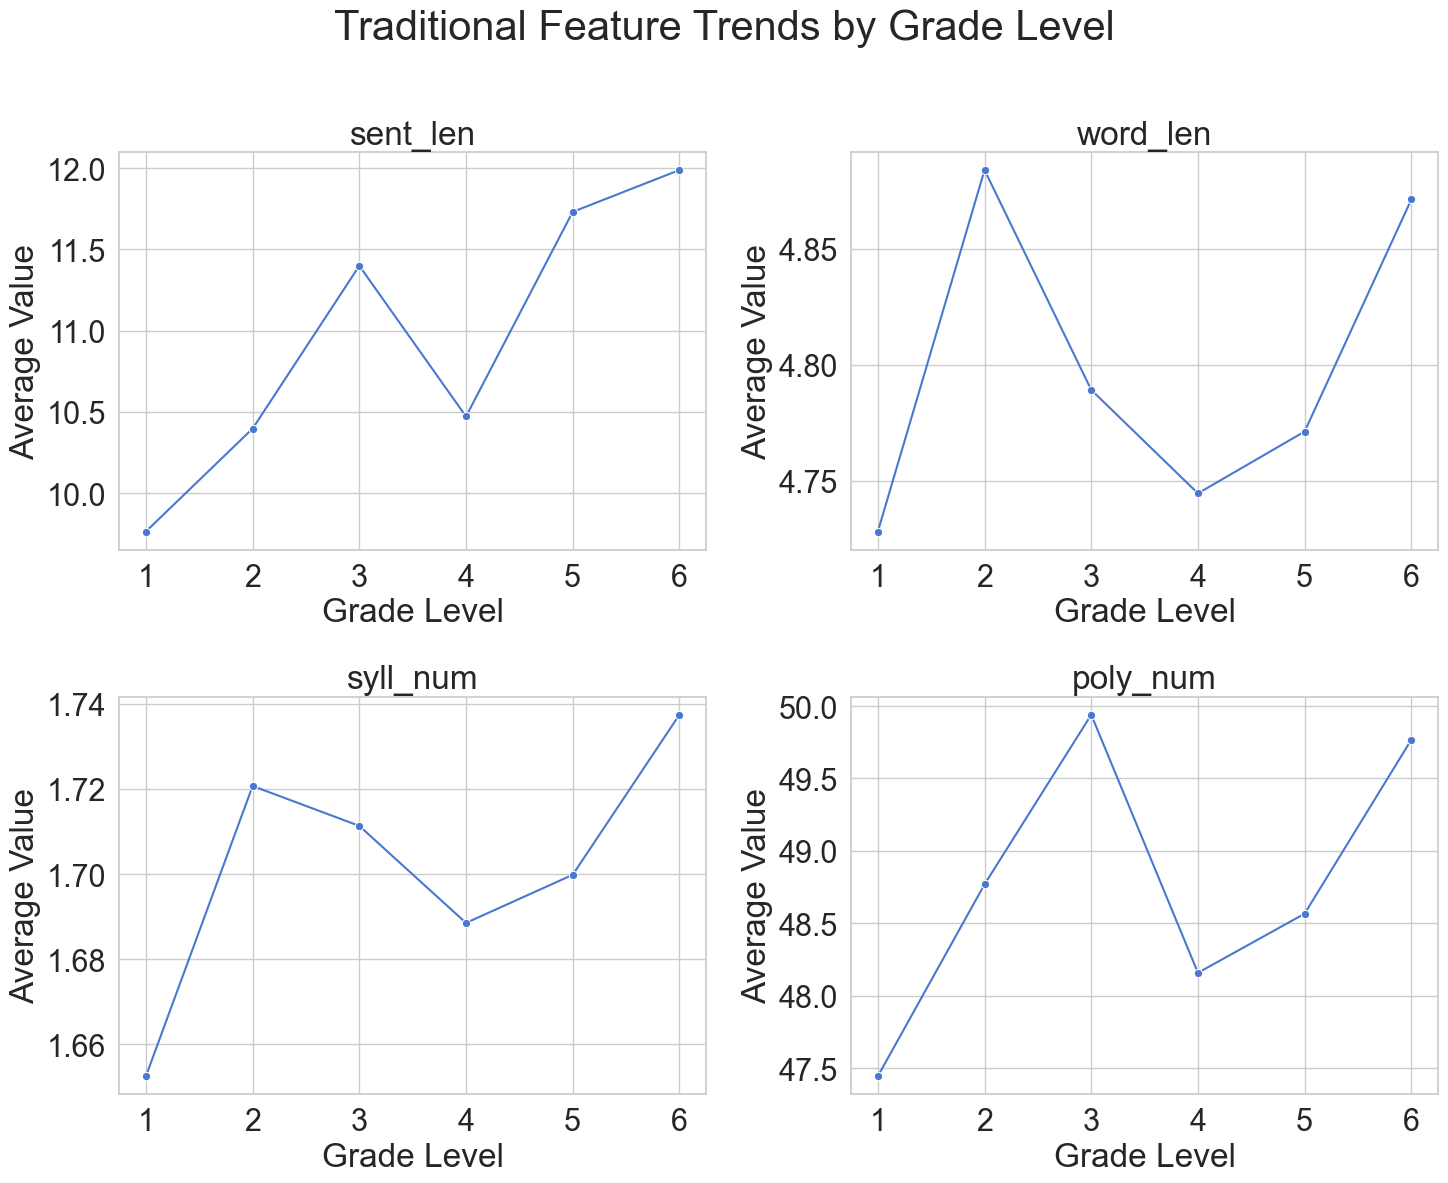

In [29]:
stride = [100]
for s in stride:
    df_filtered = df_undersampled[df_undersampled['stride_len'] == s]
    database_name = f"Stride len: {s}"

    feature_cols = [
        "sent_len", "word_len", "syll_num", "poly_num"
    ]

    # Group by grade_level and compute average feature values
    grouped = df_filtered.groupby("grade_level")[feature_cols].mean()

    # Plot setup
    sns.set(style="whitegrid", palette="muted", font_scale=2)
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
    axes = axes.flatten()

    # Plot each feature
    for i, feature in enumerate(grouped.columns):
        sns.lineplot(
            x=grouped.index.astype(str),
            y=grouped[feature],
            marker='o',
            ax=axes[i]
        )
        axes[i].set_title(f"{feature}")
        axes[i].set_xlabel("Grade Level")
        axes[i].set_ylabel("Average Value")

    plt.suptitle(f"Traditional Feature Trends by Grade Level", y=1, fontsize=30)
    plt.tight_layout()
    plt.show()


/var/folders/1x/zxvdt5995hx_mv_d5rtx8b4h0000gn/T/ipykernel_3175/3249705097.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_filtered.groupby("grade_level")[feature_cols].mean()


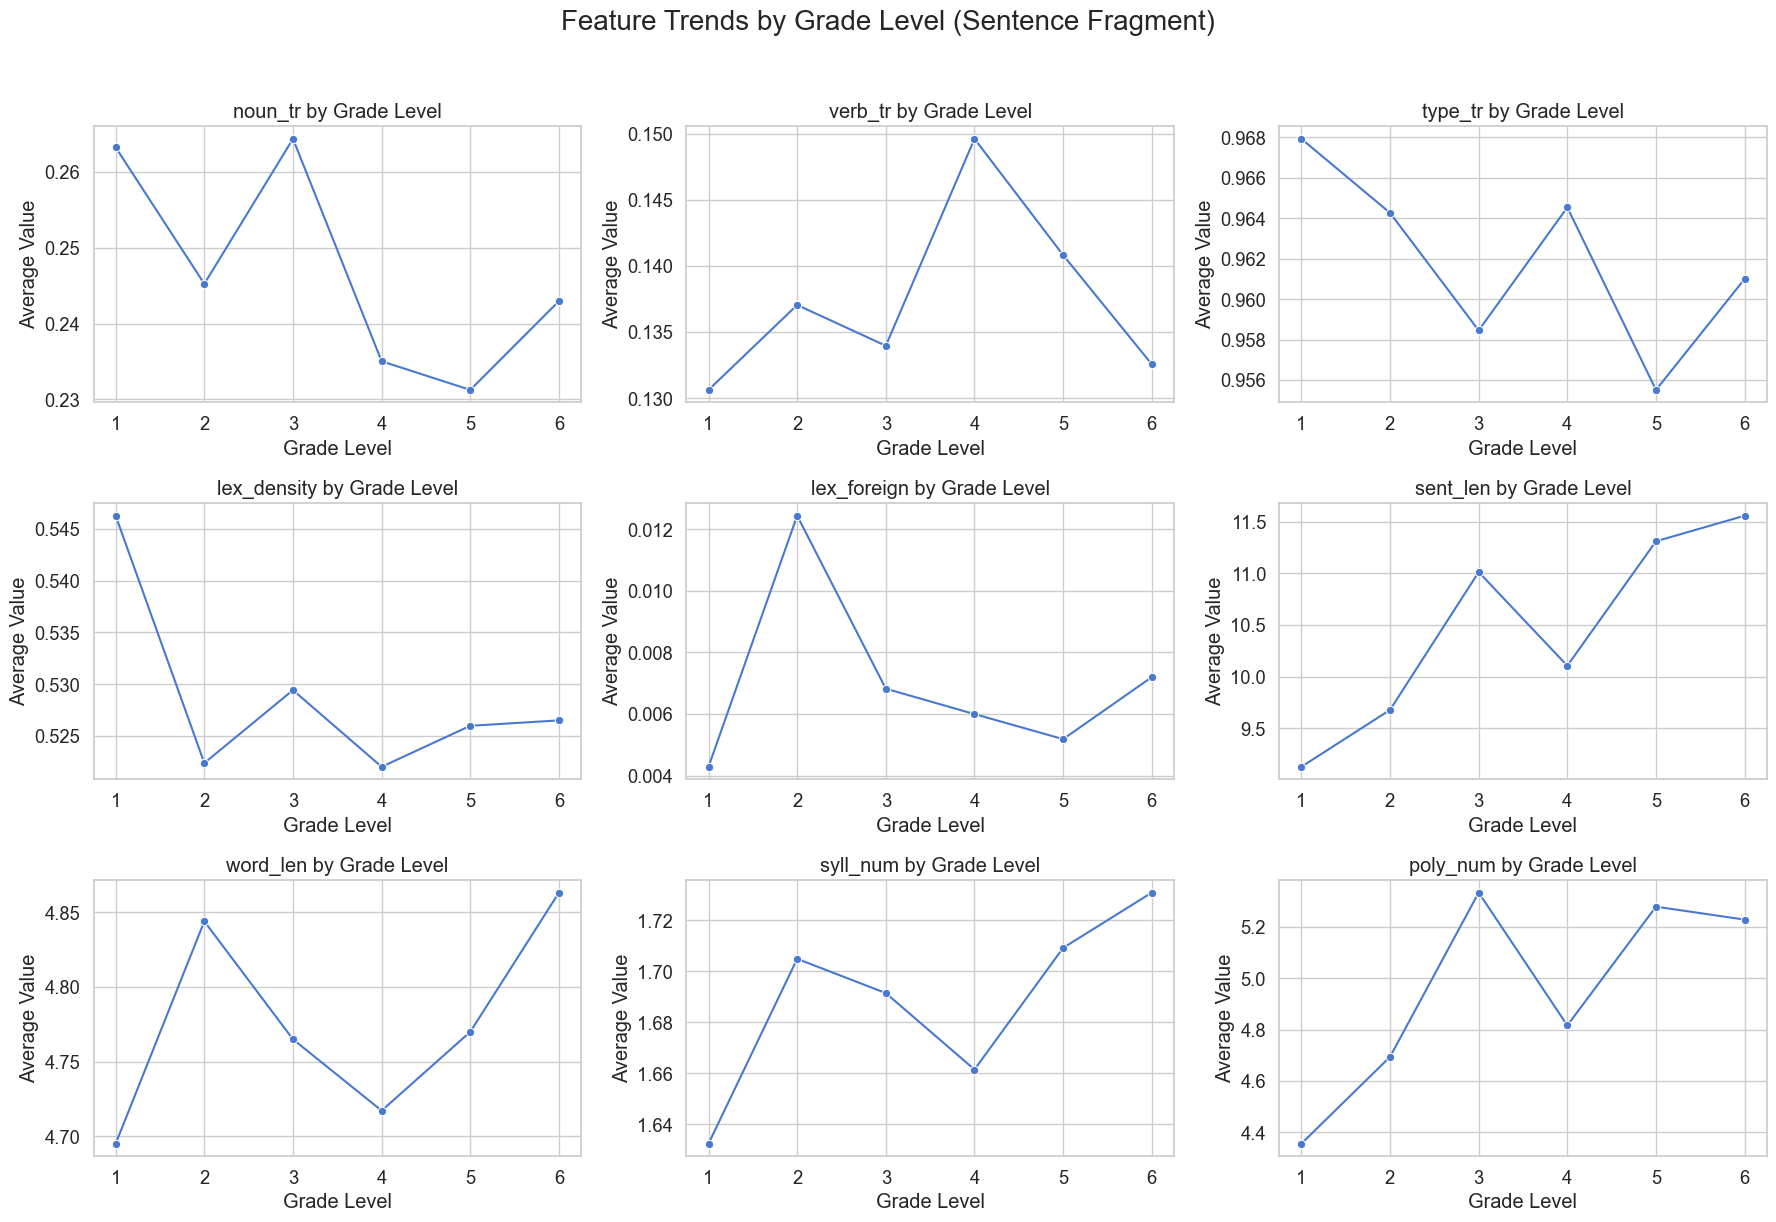

In [30]:
df_filtered = df_undersampled[(df_undersampled['stride_len'] > 3) & (df_undersampled['stride_len'] < 100)]
database_name = f"Sentence Fragment"

# df_filtered = df[df['stride_len'] > 0]
# database_name = f"Full Dataset"

feature_cols = [
    "noun_tr", "verb_tr", "type_tr", "lex_density", "lex_foreign",
    "sent_len", "word_len", "syll_num", "poly_num"
]

# Group by grade_level and compute average feature values
grouped = df_filtered.groupby("grade_level")[feature_cols].mean()

# Plot setup
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(grouped.columns):
    sns.lineplot(
        x=grouped.index.astype(str),
        y=grouped[feature],
        marker='o',
        ax=axes[i]
    )
    axes[i].set_title(f"{feature} by Grade Level")
    axes[i].set_xlabel("Grade Level")
    axes[i].set_ylabel("Average Value")

plt.suptitle(f"Feature Trends by Grade Level ({database_name})", y=1.02, fontsize=20)
plt.tight_layout()
plt.show()


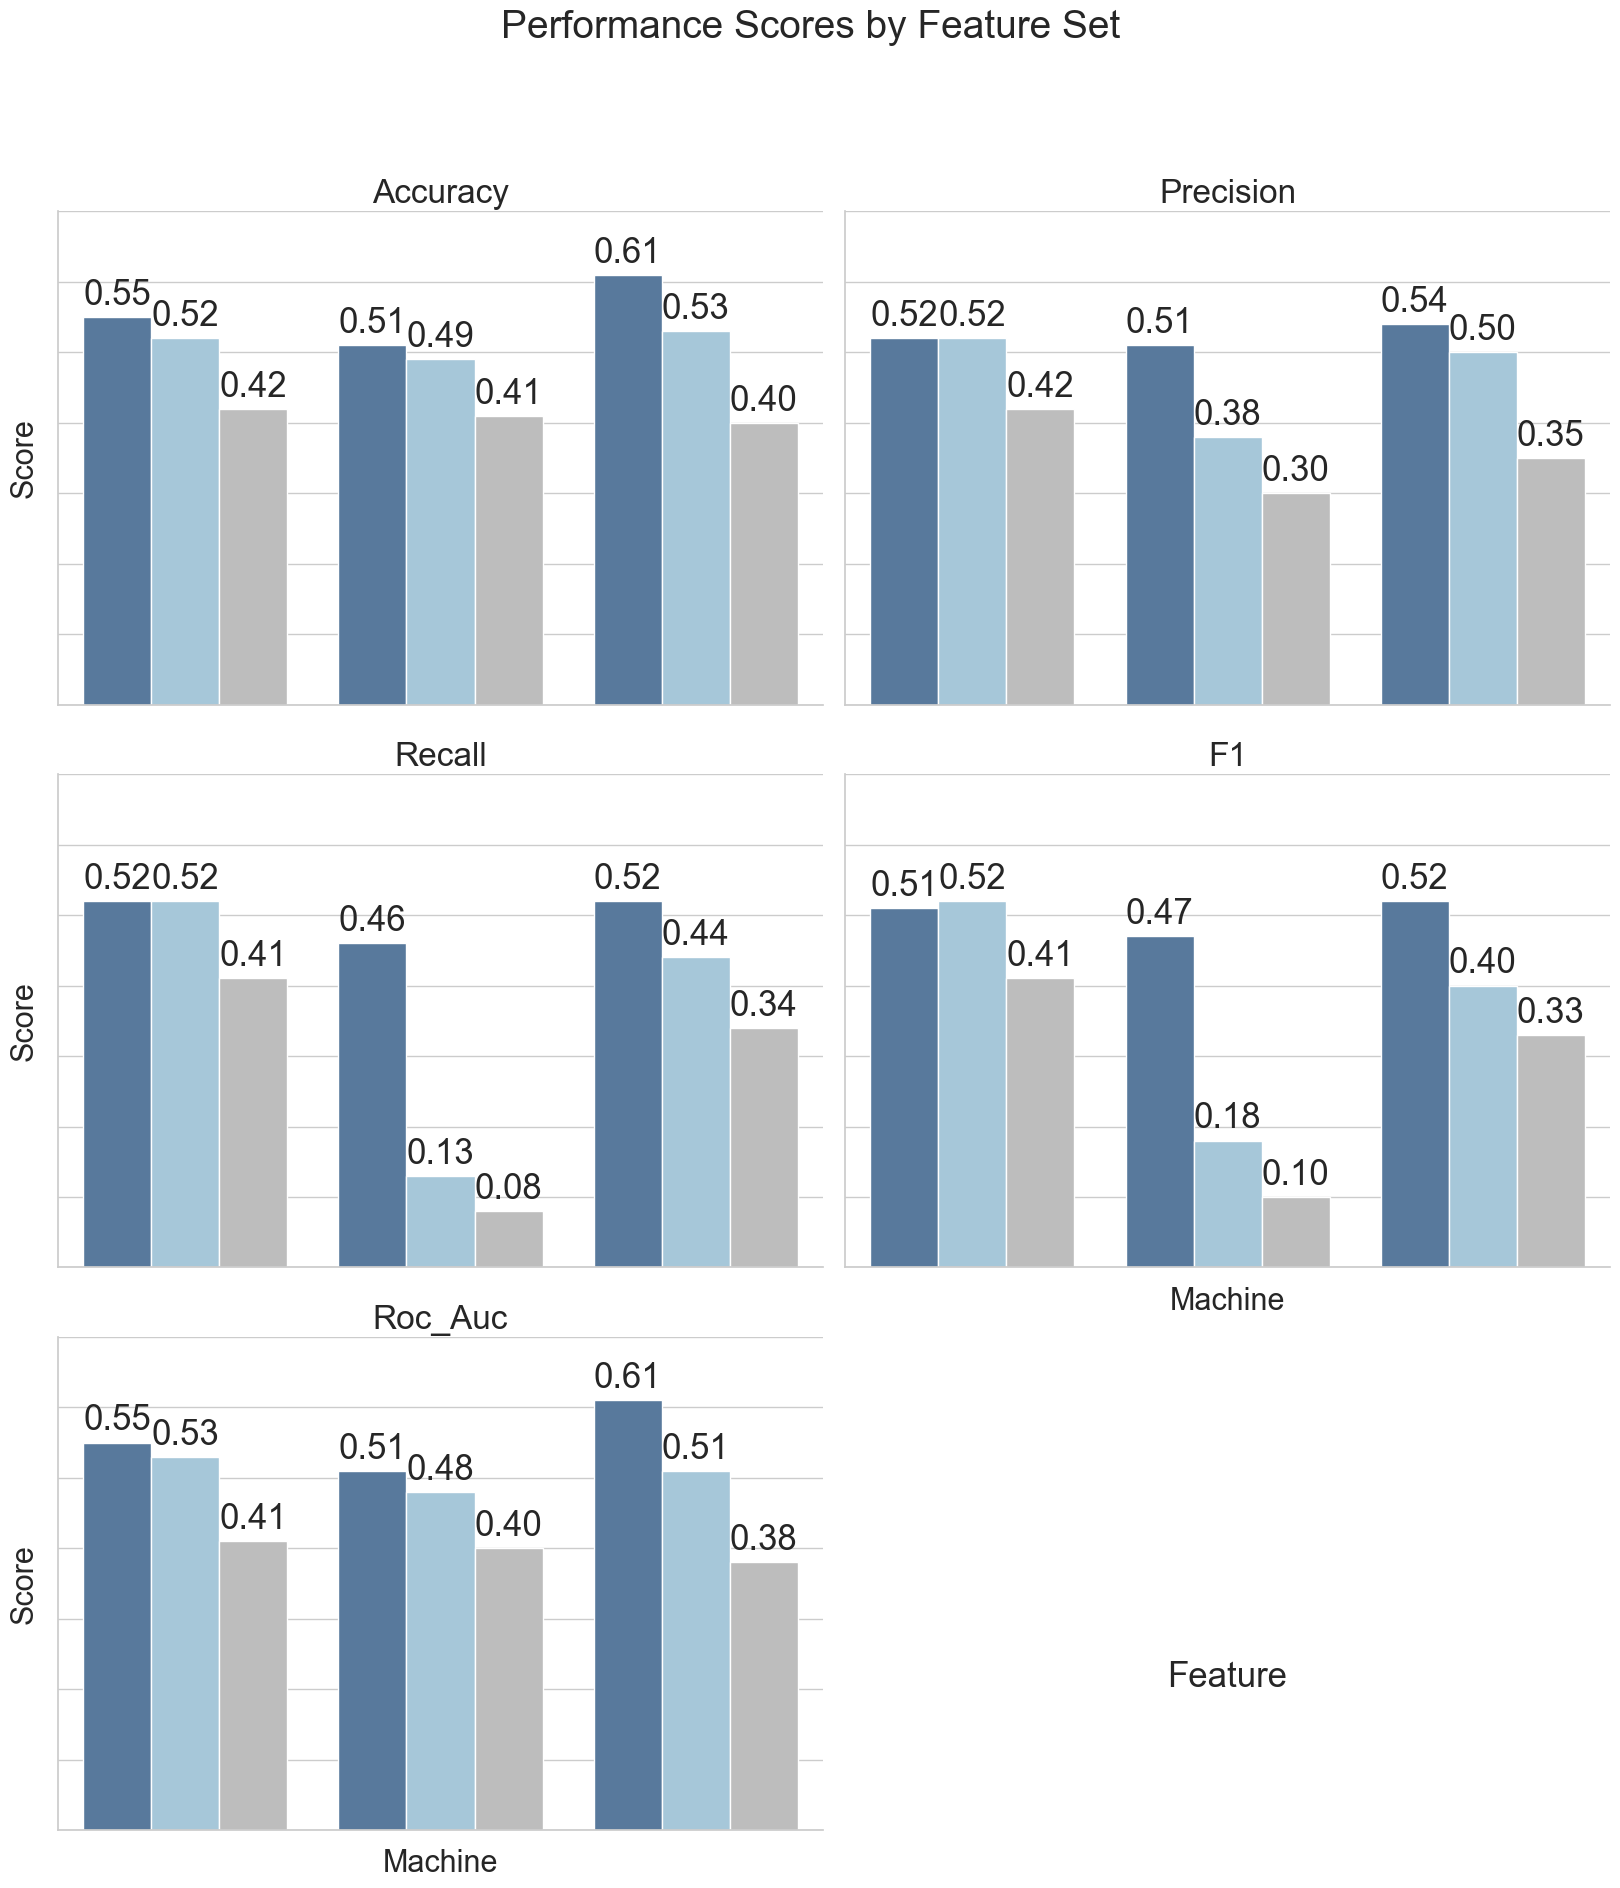

In [31]:
# Recreate the dataset from the original image values
data = {
    "Machine": ["lr", "lr", "lr", "rf", "rf", "rf", "svm", "svm", "svm"] * 5,
    "Feature": ["Trad + Lex", "Lexical", "Traditional"] * 3 * 5,
    "Score": [
        0.55, 0.52, 0.42, 0.51, 0.49, 0.41, 0.61, 0.53, 0.40,  # Accuracy
        0.52, 0.52, 0.42, 0.51, 0.38, 0.30, 0.54, 0.50, 0.35,  # Precision
        0.52, 0.52, 0.41, 0.46, 0.13, 0.08, 0.52, 0.44, 0.34,  # Recall
        0.51, 0.52, 0.41, 0.47, 0.18, 0.10, 0.52, 0.40, 0.33,  # F1
        0.55, 0.53, 0.41, 0.51, 0.48, 0.40, 0.61, 0.51, 0.38   # Roc_Auc
    ],
    "Metric": ["Accuracy"] * 9 + ["Precision"] * 9 + ["Recall"] * 9 + ["F1"] * 9 + ["Roc_Auc"] * 9
}

df = pd.DataFrame(data)

# Plot with larger fonts and no legend
g = sns.catplot(
    data=df, kind="bar",
    x="Machine", y="Score", hue="Feature",
    col="Metric", col_wrap=2,  # 3 columns per row
    height=6, aspect=1.3,
    palette=["#4C78A8", "#9ECae1", "#BDBDBD"],
    legend=False
)

# Remove all legends from axes BEFORE adding your custom legend
for ax in g.axes.flat:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Now add your custom legend
g.add_legend(title="Feature", loc="lower right", bbox_to_anchor=(0.8, 0.1))


# Enlarge legend font
for text in g._legend.texts:
    text.set_fontsize(25)  # Set your desired font size here
g._legend.set_title("Feature")
g._legend.get_title().set_fontsize(25)  # Set legend title font size


# Customize fonts
g.set_titles("{col_name}", size=24)
g.set_axis_labels("Machine", "Score", size=22)
g.set_xticklabels(size=20)
g.set_yticklabels(size=20)

# Add bar annotations
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=25, padding=4)

# Title
g.fig.suptitle("Performance Scores by Feature Set", fontsize=28, y=1.05)
plt.tight_layout()
plt.show()

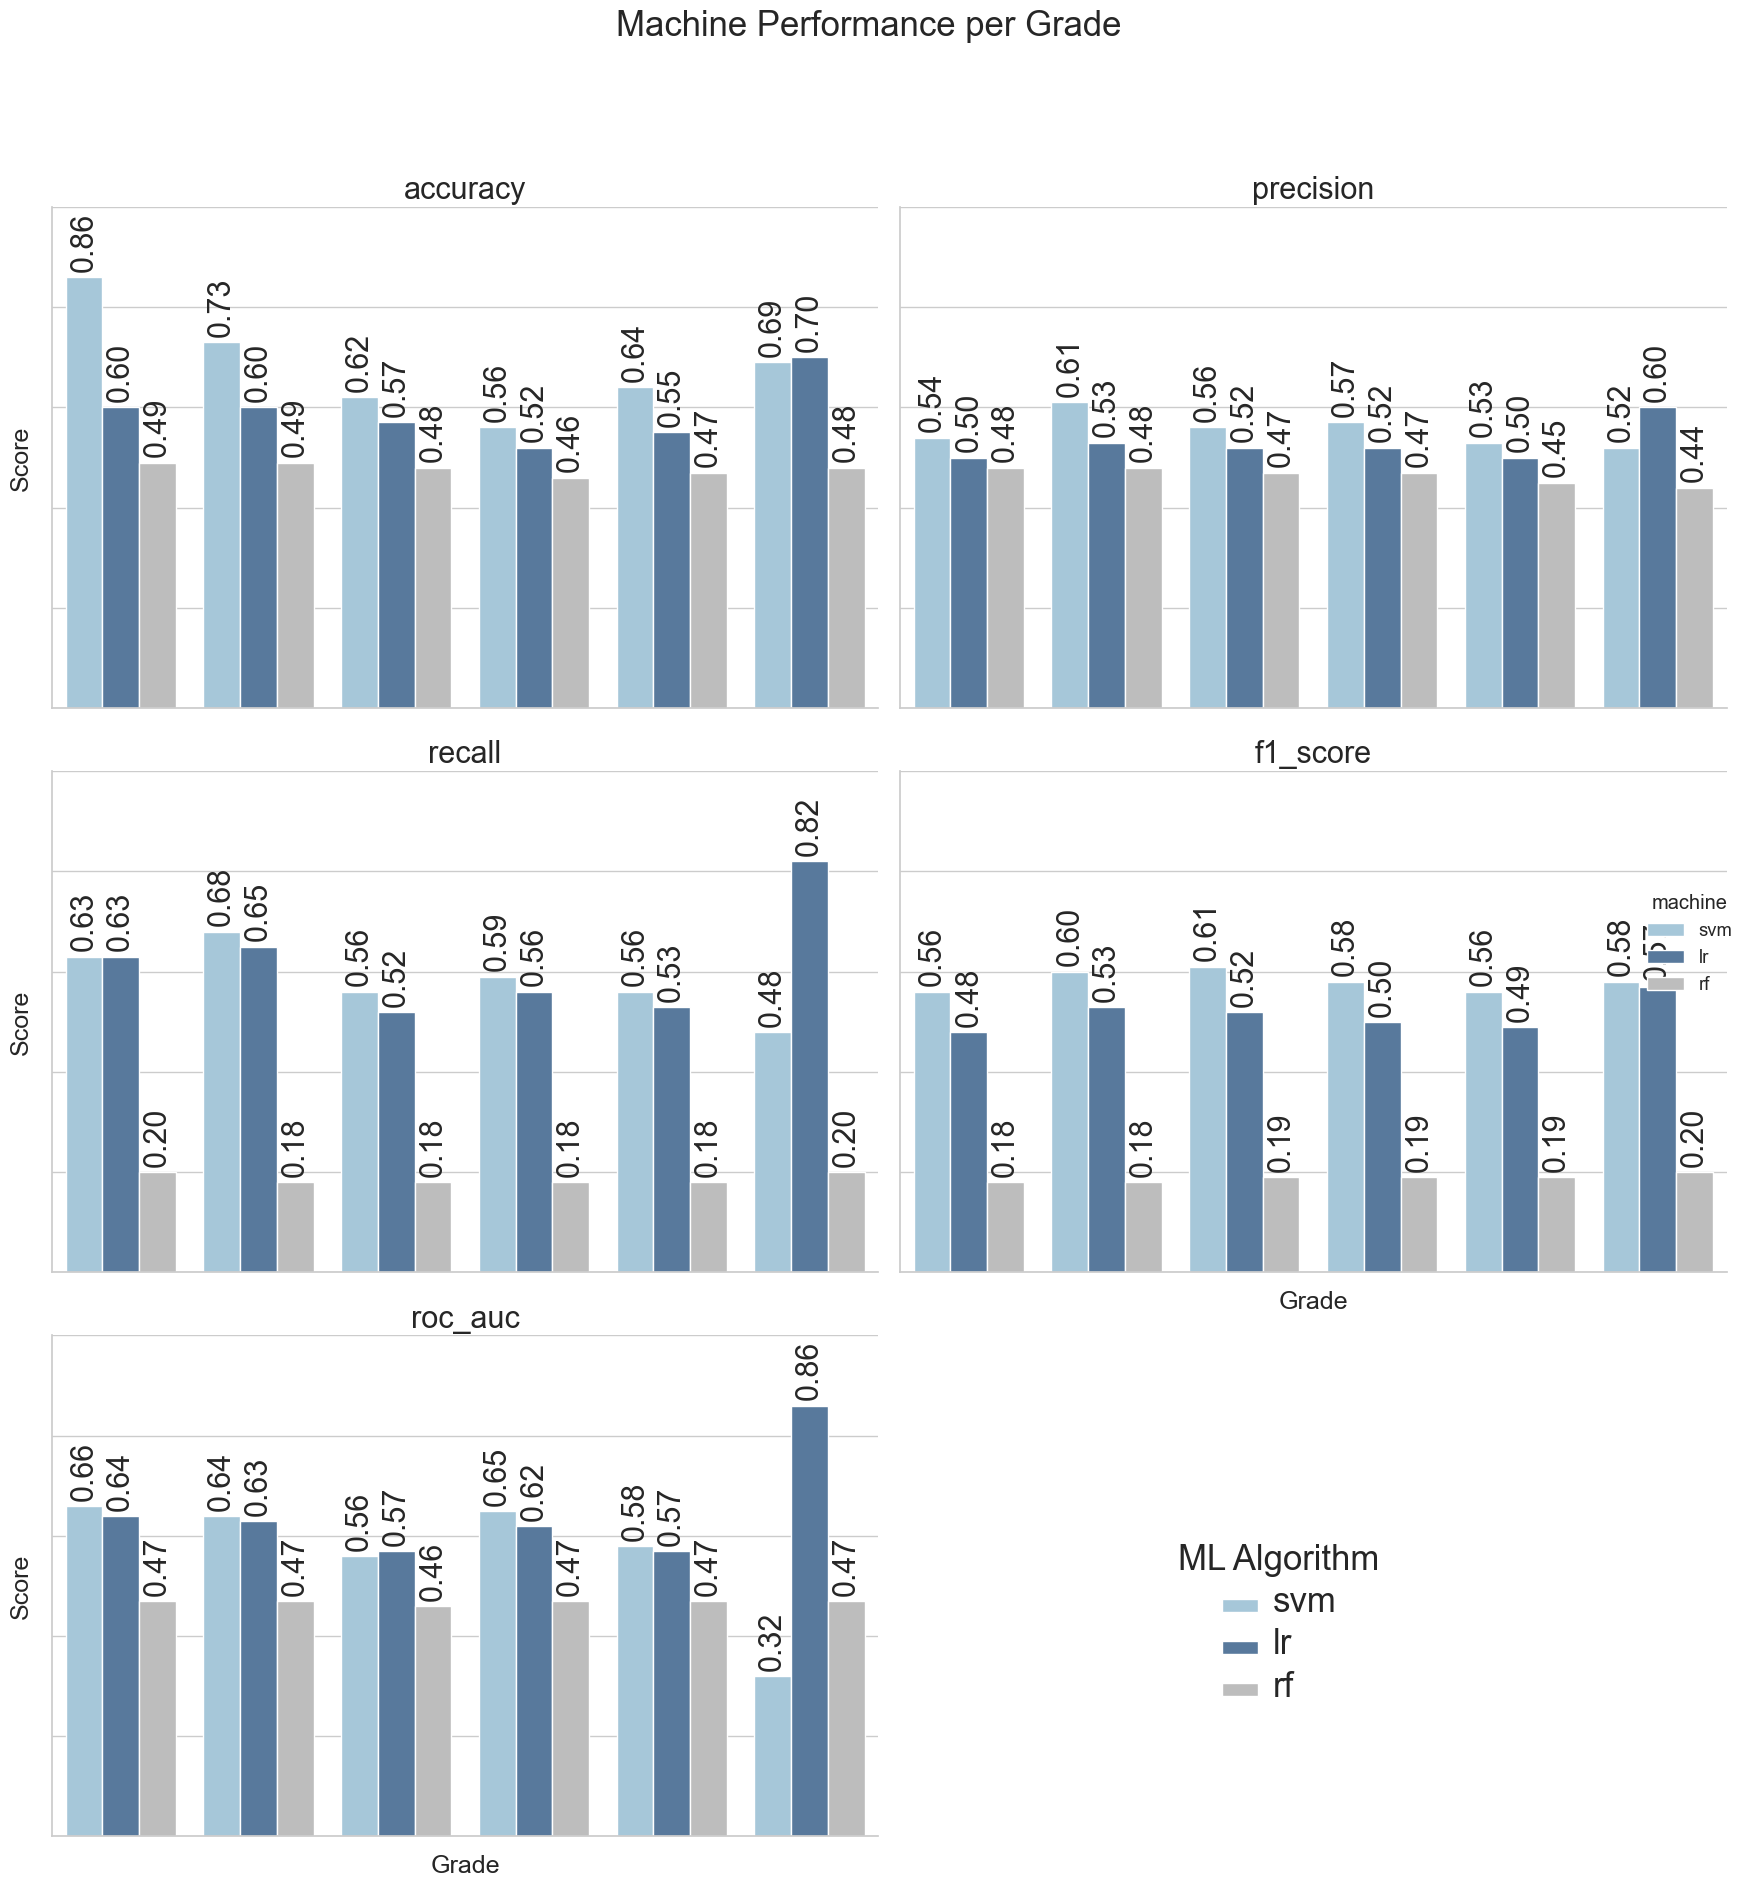

In [32]:
# Define consistent length of entries
grades = [1, 2, 3, 4, 5, 6]
machines = ["svm", "lr", "rf"]
metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

# Define score values as nested dictionary
scores = {
    "accuracy": {
        "svm": [0.86, 0.73, 0.62, 0.56, 0.64, 0.69],
        "lr": [0.60, 0.60, 0.57, 0.52, 0.55, 0.70],
        "rf": [0.49, 0.49, 0.48, 0.46, 0.47, 0.48]
    },
    "precision": {
        "svm": [0.54, 0.61, 0.56, 0.57, 0.53, 0.52],
        "lr": [0.50, 0.53, 0.52, 0.52, 0.50, 0.60],
        "rf": [0.48, 0.48, 0.47, 0.47, 0.45, 0.44]
    },
    "recall": {
        "svm": [0.63, 0.68, 0.56, 0.59, 0.56, 0.48],
        "lr": [0.63, 0.65, 0.52, 0.56, 0.53, 0.82],
        "rf": [0.20, 0.18, 0.18, 0.18, 0.18, 0.20]
    },
    "f1_score": {
        "svm": [0.56, 0.60, 0.61, 0.58, 0.56, 0.58],
        "lr": [0.48, 0.53, 0.52, 0.50, 0.49, 0.57],
        "rf": [0.18, 0.18, 0.19, 0.19, 0.19, 0.20]
    },
    "roc_auc": {
        "svm": [0.66, 0.64, 0.56, 0.65, 0.58, 0.32],
        "lr": [0.64, 0.63, 0.57, 0.62, 0.57, 0.86],
        "rf": [0.47, 0.47, 0.46, 0.47, 0.47, 0.47]
    }
}

# Flatten the nested dictionary into a DataFrame
records = []
for metric in metrics:
    for machine in machines:
        for i, grade in enumerate(grades):
            records.append({
                "grade": grade,
                "machine": machine,
                "Metric": metric,
                "Score": scores[metric][machine][i]
            })

df_grade = pd.DataFrame(records)

# Plot with large fonts and no legend
g = sns.catplot(
    data=df_grade, kind="bar",
    x="grade", y="Score", hue="machine",
    col="Metric", col_wrap=2,
    height=6, aspect=1.3,
    palette=["#9ECae1", "#4C78A8", "#BDBDBD"],
    legend=True
)

# Now add your custom legend
g.add_legend(title="machine", loc="lower right", bbox_to_anchor=(0.8, 0.1))


# Enlarge legend font
for text in g._legend.texts:
    text.set_fontsize(25)  # Set your desired font size here
g._legend.set_title("ML Algorithm")
g._legend.get_title().set_fontsize(25)  # Set legend title font size

g.set_titles("{col_name}", size=22)
g.set_axis_labels("Grade", "Score", size=18)
g.set_xticklabels(size=15)
g.set_yticklabels(size=15)

# Add annotations
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            label_type="edge",
            fontsize=22,
            padding=4,
            rotation=90  # Rotate labels -90 degrees
        )

g.fig.suptitle("Machine Performance per Grade", fontsize=25, y=1.05)
plt.tight_layout()
plt.show()